## 1. Метод линеаризации Ньютона (квазилинеаризация)

Нам дана краевая задача:
$$\varepsilon y'' - y + y^3 = 0$$
$$y(0) = A, \quad y(1) = B$$

Будем искать решение с помощью итерационного метода Ньютона-Канторовича. Пусть $y_k(x)$ — известное приближение на $k$-ой итерации. Следующее приближение ищем в виде $y_{k+1} = y_k + \delta y$. 

Подставим это в исходное уравнение:
$$\varepsilon (y_k'' + \delta y'') - (y_k + \delta y) + (y_k + \delta y)^3 = 0$$

Раскроем куб суммы и оставим только линейные по $\delta y$ члены (линеаризация):
$$(y_k + \delta y)^3 \approx y_k^3 + 3y_k^2 \delta y$$

Получаем линейное дифференциальное уравнение для поправки $\delta y$:
$$\varepsilon \delta y'' + (3y_k^2 - 1)\delta y = -(\varepsilon y_k'' - y_k + y_k^3)$$

Граничные условия для поправки нулевые, так как $y_k$ уже должно удовлетворять граничным условиям задачи:
$$\delta y(0) = A, \quad \delta y(1) = B$$

### Аппроксимация
Введем равномерную сетку $x_j = j h$, где $h = 1/N$. Вторую производную аппроксимируем центральной разностью:
$$y'' \approx \frac{y_{j-1} - 2y_j + y_{j+1}}{h^2}$$

Тогда дискретный аналог уравнения для поправки примет вид:
$$\frac{\varepsilon}{h^2} \delta y_{j-1} + \left( 3y_{k,j}^2 - 1 - \frac{2\varepsilon}{h^2} \right) \delta y_j + \frac{\varepsilon}{h^2} \delta y_{j+1} = -F(y_{k, j})$$
где $F(y_{k, j}) = \varepsilon \frac{y_{k, j-1} - 2y_{k, j} + y_{k, j+1}}{h^2} - y_{k, j} + y_{k, j}^3$.

Полученная система линейных алгебраических уравнений (СЛАУ) имеет трехдиагональную матрицу и эффективно решается методом прогонки.

## 2. Начальное приближения

Ключевой момент задачи — обнаружение «пиковых» структур при $n=2$ (один пик в $x=1/2$) и $n=3$ (два пика в $x=1/3$ и $x=2/3$). 
Если в уравнении $\varepsilon y'' - y + y^3 = 0$ сделать замену переменной $\xi = (x-x_0)/\sqrt{\varepsilon}$ (растяжение координат в зоне пика), мы получим уравнение $Y'' - Y + Y^3 = 0$. 

Его аналитическое решение, затухающее на бесконечности (солитонного типа), имеет вид:
$$Y(\xi) = \frac{\sqrt{2}}{\cosh(\xi/\sqrt{2})}$$

Возвращаясь к нашим переменным, идеальное начальное приближение для пика с центром в точке $x_i$:
$$y_{init}(x) \approx \frac{\sqrt{2}}{\cosh\left(\frac{x - x_i}{\sqrt{2\varepsilon}}\right)}$$

Мы будем суммировать такие функции для $x_i = i/n$, чтобы задать начальную форму профиля для метода Ньютона.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

def solve_spike_bvp(eps, n_intervals, A=0.0, B=0.0, N=2000, max_iter=50, tol=1e-6):
    h = 1.0 / N
    x = np.linspace(0, 1, N + 1)
    
    # 1. Формируем начальное приближение (берем огибающую, а не сумму!)
    y = np.linspace(A, B, N + 1)
    
    for i in range(1, n_intervals):
        x_i = i / n_intervals
        spike = np.sqrt(2) / np.cosh((x - x_i) / np.sqrt(2 * eps))
        # используем максимум, чтобы пики не суммировались > sqrt(2)
        y = np.maximum(y, spike)
        
    y[0] = A
    y[-1] = B
    
    # 2. Итерации Ньютона
    for it in range(max_iter):
        d2y = (y[:-2] - 2*y[1:-1] + y[2:]) / h**2
        
        F = eps * d2y - y[1:-1] + y[1:-1]**3
        RHS = -F
        
        main_diag = 3 * y[1:-1]**2 - 1 - 2 * eps / h**2
        off_diag = (eps / h**2) * np.ones(N - 2)
        
        A_mat = diags([off_diag, main_diag, off_diag], [-1, 0, 1], format='csr')
        dy_inner = spsolve(A_mat, RHS)
        
        dy = np.zeros(N + 1)
        dy[1:-1] = dy_inner
        y += dy
        
        if np.linalg.norm(dy, np.inf) < tol:
            print(f"[eps={eps}, n={n_intervals}] Сошлось за {it+1} итераций.")
            break
    else:
        print(f"[eps={eps}, n={n_intervals}] ВНИМАНИЕ: Не сошлось за {max_iter} итераций! Ошибка: {np.linalg.norm(dy, np.inf):.2e}")
        
    return x, y

<>:14: SyntaxWarning: invalid escape sequence '\e'
<>:16: SyntaxWarning: invalid escape sequence '\l'
<>:28: SyntaxWarning: invalid escape sequence '\e'
<>:14: SyntaxWarning: invalid escape sequence '\e'
<>:16: SyntaxWarning: invalid escape sequence '\l'
<>:28: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_4735/3117315527.py:14: SyntaxWarning: invalid escape sequence '\e'
  plt.plot(x, y, label=f'$\epsilon = 10^{{{int(np.log10(eps))}}}$')
/tmp/ipykernel_4735/3117315527.py:16: SyntaxWarning: invalid escape sequence '\l'
  plt.axhline(np.sqrt(2), color='gray', linestyle='--', alpha=0.5, label='$\lim = \sqrt{2}$')
/tmp/ipykernel_4735/3117315527.py:28: SyntaxWarning: invalid escape sequence '\e'
  plt.plot(x, y, label=f'$\epsilon = 10^{{{int(np.log10(eps))}}}$')


[eps=0.01, n=2] ВНИМАНИЕ: Не сошлось за 50 итераций! Ошибка: 1.77e+04
[eps=0.001, n=2] Сошлось за 7 итераций.
[eps=0.0001, n=2] ВНИМАНИЕ: Не сошлось за 50 итераций! Ошибка: 2.21e+03
[eps=0.01, n=3] ВНИМАНИЕ: Не сошлось за 50 итераций! Ошибка: 5.11e+04
[eps=0.001, n=3] Сошлось за 12 итераций.
[eps=0.0001, n=3] Сошлось за 9 итераций.


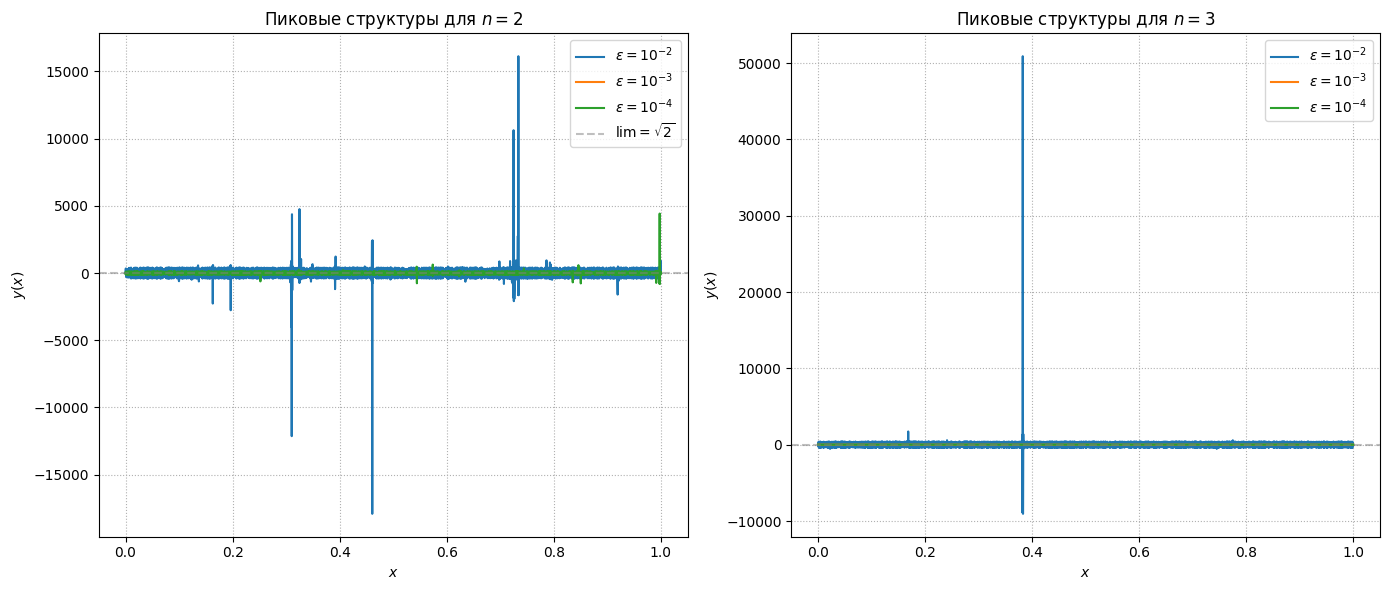

In [8]:
eps_values = [1e-2, 1e-3, 1e-4]
# Берем A и B равными 0, так как |0| < sqrt(2)
A_val, B_val = 1, 1 

plt.figure(figsize=(14, 6))

# --- Случай n = 2 ---
plt.subplot(1, 2, 1)
plt.title("Пиковые структуры для $n=2$")
for eps in eps_values:
    # Для eps=1e-4 сетку лучше сделать гуще, чтобы поймать очень узкий пик
    N_grid = 5000 if eps == 1e-4 else 2000 
    x, y = solve_spike_bvp(eps, n_intervals=2, A=A_val, B=B_val, N=N_grid)
    plt.plot(x, y, label=f'$\epsilon = 10^{{{int(np.log10(eps))}}}$')

plt.axhline(np.sqrt(2), color='gray', linestyle='--', alpha=0.5, label='$\lim = \sqrt{2}$')
plt.xlabel('$x$')
plt.ylabel('$y(x)$')
plt.grid(True, linestyle=':')
plt.legend()

# --- Случай n = 3 ---
plt.subplot(1, 2, 2)
plt.title("Пиковые структуры для $n=3$")
for eps in eps_values:
    N_grid = 5000 if eps == 1e-4 else 2000
    x, y = solve_spike_bvp(eps, n_intervals=3, A=A_val, B=B_val, N=N_grid)
    plt.plot(x, y, label=f'$\epsilon = 10^{{{int(np.log10(eps))}}}$')

plt.axhline(np.sqrt(2), color='gray', linestyle='--', alpha=0.5)
plt.xlabel('$x$')
plt.ylabel('$y(x)$')
plt.grid(True, linestyle=':')
plt.legend()

plt.tight_layout()
plt.show()